# TOÁN ỨNG DỤNG TRONG QUẢN TRỊ RỦI RO VÀ PHÂN BỔ ĐẦU TƯ

# ĐỌC DATA

In [98]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [99]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


df = pd.read_csv('/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/Portfolio.csv', parse_dates=['DATE'])


df_plx = df[df['SYMBOL'] == 'PLX'].copy()
df_ssi = df[df['SYMBOL'] == 'SSI'].copy()
df_vnm = df[df['SYMBOL'] == 'VNM'].copy()

# TỶ LỆ PHÂN BỔ VỐN

In [100]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

labels = ["PLX", "SSI", "VNM"]

fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])
fig.add_trace(go.Pie(labels=labels, values=[24.80, 38.92, 36.28], name="Percentage"),
              1, 1)
fig.add_trace(go.Pie(labels=labels, values=[2000, 5000, 2000], name="Volume", textinfo='label+value'),
              1, 2)

fig.update_traces(hole=.4, hoverinfo="label+percent+name")

fig.update_layout(
    title_text="CAPITAL ALLOCATION RATIO",
    annotations=[dict(text='PER', x=sum(fig.get_subplot(1, 1).x) / 2, y=0.5,
                      font_size=20, showarrow=False, xanchor="center"),
                 dict(text='VOL', x=sum(fig.get_subplot(1, 2).x) / 2, y=0.5,font_size=20, showarrow=False, xanchor="center")])
fig.show()

# HIỆU SUẤT CỦA DANH MỤC KHI SO VỚI VN-INDEX

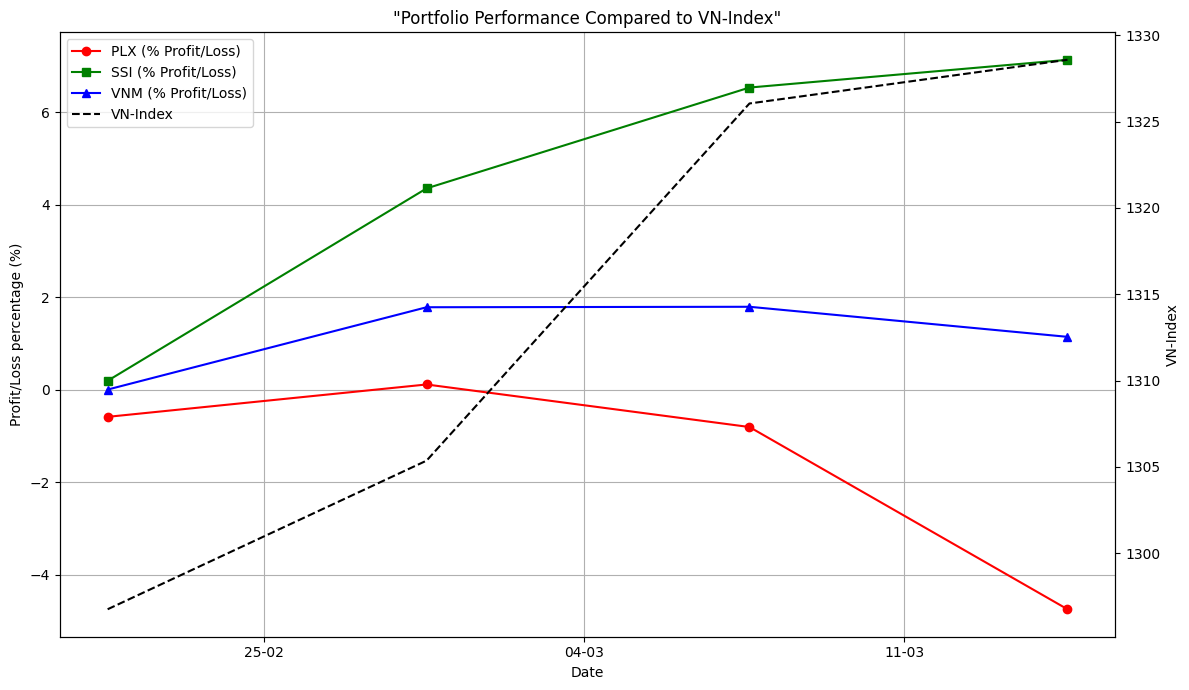

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/Portfolio.csv', parse_dates=['DATE'])

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.plot(df[df['SYMBOL'] == 'PLX']['DATE'], df[df['SYMBOL'] == 'PLX']['PROFIT/LOSS (%)'], 
         'r-o', label='PLX (% Profit/Loss)')
ax1.plot(df[df['SYMBOL'] == 'SSI']['DATE'], df[df['SYMBOL'] == 'SSI']['PROFIT/LOSS (%)'], 
         'g-s', label='SSI (% Profit/Loss)')
ax1.plot(df[df['SYMBOL'] == 'VNM']['DATE'], df[df['SYMBOL'] == 'VNM']['PROFIT/LOSS (%)'], 
         'b-^', label='VNM (% Profit/Loss)')

ax1.set_xlabel('Date')
ax1.set_ylabel('Profit/Loss percentage (%)')
ax1.set_title('"Portfolio Performance Compared to VN-Index"')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(df.groupby('DATE')['VN-INDEX (Last)'].first(), 'k--', label='VN-Index')
ax2.set_ylabel('VN-Index')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=7))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# TỔNG GIÁ TRỊ TÀI SẢN THEO THỜI GIAN

/var/folders/2w/0ds979vs33z3m70t85hh_cp00000gn/T/ipykernel_28122/3003482468.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Text(0, 0.5, 'Value (VND)')

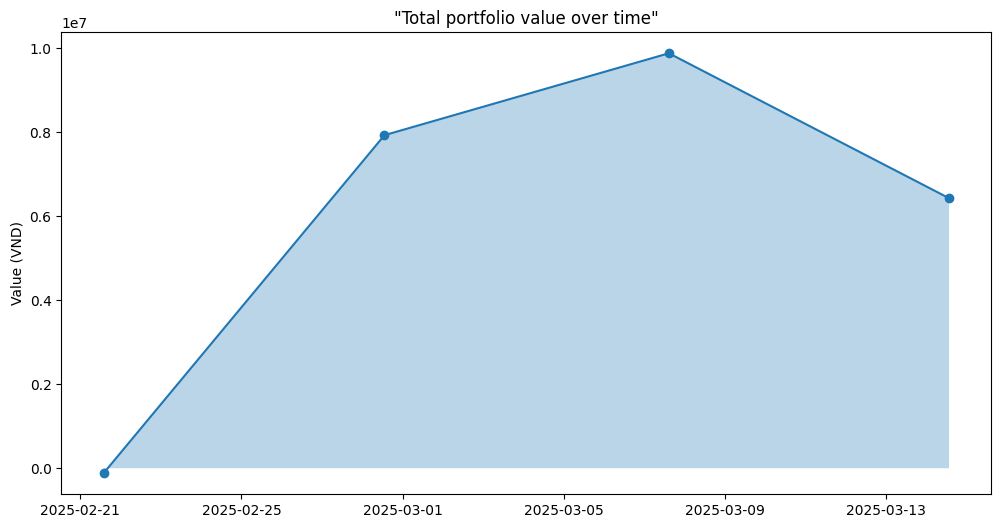

In [102]:
# Tính tổng giá trị theo thời gian
portfolio_value = df.groupby('DATE').apply(lambda x: x['SUM'].sum() + x['CAPITAL'].sum())

plt.figure(figsize=(12,6))
plt.fill_between(portfolio_value.index, portfolio_value, alpha=0.3)
plt.plot(portfolio_value.index, portfolio_value, marker='o')
plt.title('"Total portfolio value over time"')
plt.ylabel('Value (VND)')

# DÒNG TIỀN

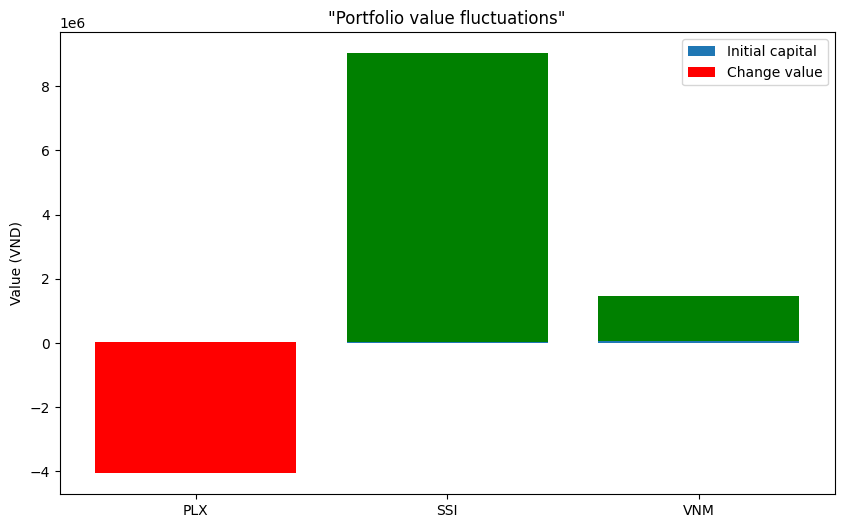

In [103]:
# Tính toán vốn ban đầu và hiện tại
initial_cap = df.groupby('SYMBOL')['CAPITAL'].first()
current_value = df.groupby('SYMBOL').last()['SUM'] + initial_cap

# Waterfall chart
fig, ax = plt.subplots(figsize=(10,6))
waterfall_df = pd.DataFrame({
    'Start': initial_cap,
    'End': current_value,
    'Change': current_value - initial_cap
}, index=initial_cap.index)

ax.bar(waterfall_df.index, waterfall_df['Start'], label='Initial capital')
ax.bar(waterfall_df.index, waterfall_df['Change'], bottom=waterfall_df['Start'], 
       color=['red' if x<0 else 'green' for x in waterfall_df['Change']],
       label='Change value')
ax.set_title('"Portfolio value fluctuations"')
ax.set_ylabel('Value (VND)')
ax.legend()

# BIẾN ĐỘNG RỦI RO VỀ GIÁ

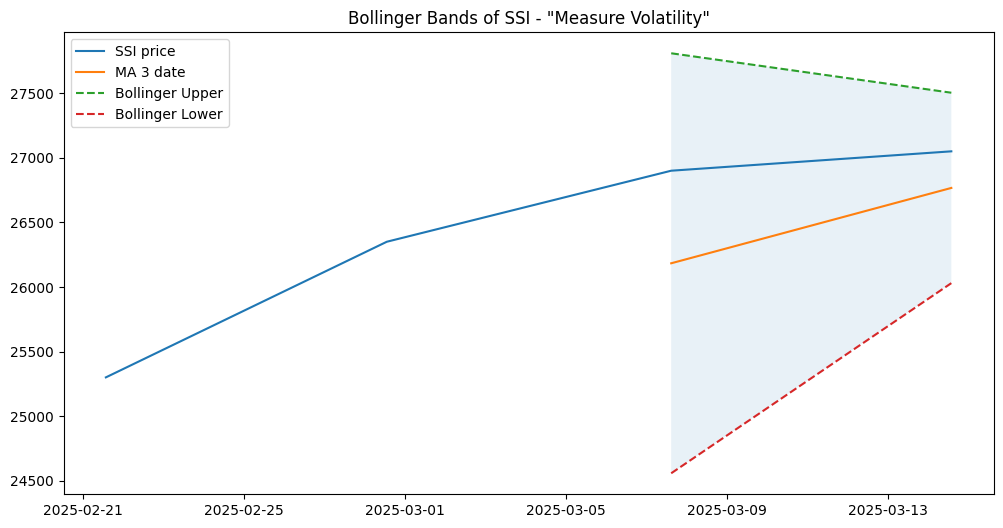

In [104]:
# Tính toán cho SSI 
ssi = df[df['SYMBOL']=='SSI'].set_index('DATE')
window = 3
ssi['MA'] = ssi['REFERENCE PRICE'].rolling(window).mean()
ssi['Upper'] = ssi['MA'] + 2*ssi['REFERENCE PRICE'].rolling(window).std()
ssi['Lower'] = ssi['MA'] - 2*ssi['REFERENCE PRICE'].rolling(window).std()

plt.figure(figsize=(12,6))
plt.plot(ssi.index, ssi['REFERENCE PRICE'], label='SSI price')
plt.plot(ssi.index, ssi['MA'], label=f'MA {window} date')
plt.plot(ssi.index, ssi['Upper'], '--', label='Bollinger Upper')
plt.plot(ssi.index, ssi['Lower'], '--', label='Bollinger Lower')
plt.fill_between(ssi.index, ssi['Upper'], ssi['Lower'], alpha=0.1)
plt.title('Bollinger Bands of SSI - "Measure Volatility"')
plt.legend()

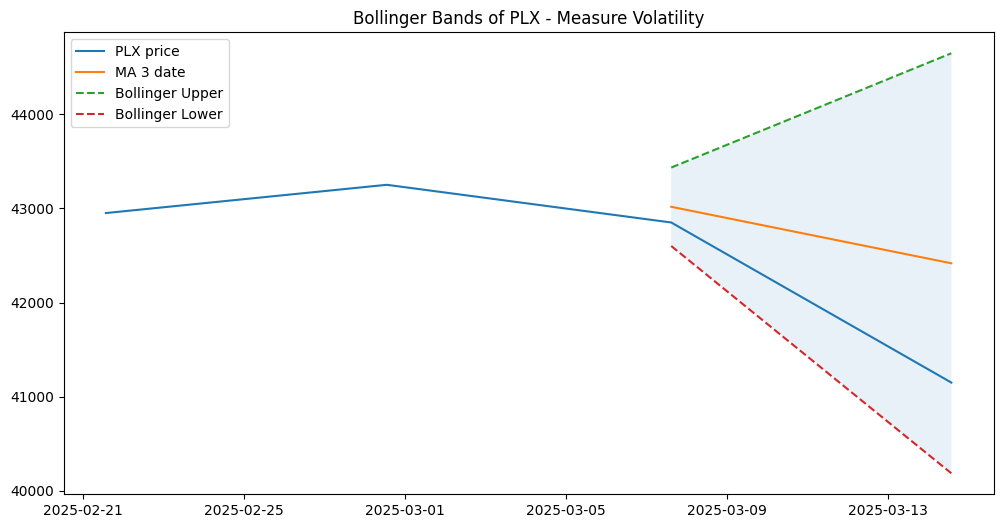

In [105]:
plx = df[df['SYMBOL']=='PLX'].set_index('DATE')
window = 3
plx['MA'] = plx['REFERENCE PRICE'].rolling(window).mean()
plx['Upper'] = plx['MA'] + 2*plx['REFERENCE PRICE'].rolling(window).std()
plx['Lower'] = plx['MA'] - 2*plx['REFERENCE PRICE'].rolling(window).std()

plt.figure(figsize=(12,6))
plt.plot(plx.index, plx['REFERENCE PRICE'], label='PLX price')
plt.plot(plx.index, plx['MA'], label=f'MA {window} date')
plt.plot(plx.index, plx['Upper'], '--', label='Bollinger Upper')
plt.plot(plx.index, plx['Lower'], '--', label='Bollinger Lower')
plt.fill_between(plx.index, plx['Upper'], plx['Lower'], alpha=0.1)
plt.title('Bollinger Bands of PLX - Measure Volatility')
plt.legend()

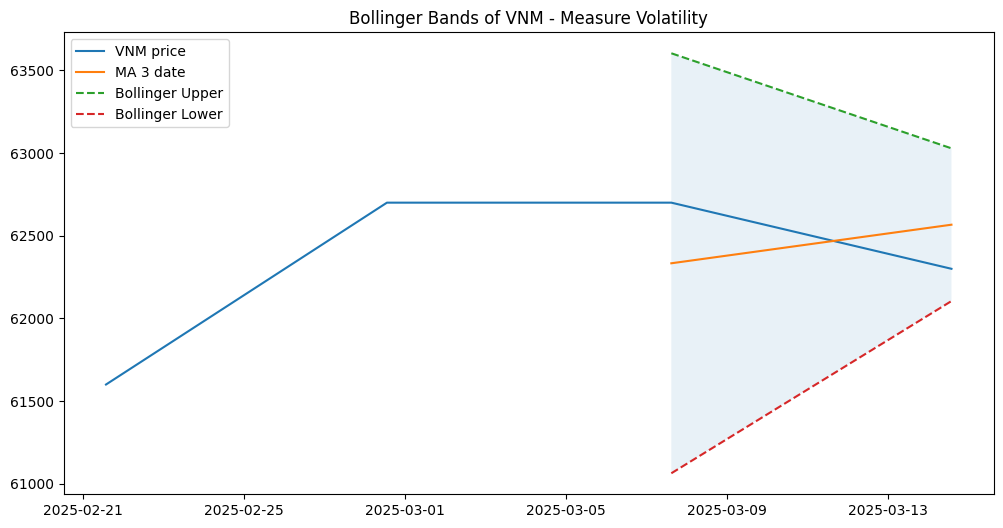

In [106]:
vnm = df[df['SYMBOL']=='VNM'].set_index('DATE')
window = 3
vnm['MA'] = vnm['REFERENCE PRICE'].rolling(window).mean()
vnm['Upper'] = vnm['MA'] + 2*vnm['REFERENCE PRICE'].rolling(window).std()
vnm['Lower'] = vnm['MA'] - 2*vnm['REFERENCE PRICE'].rolling(window).std()

plt.figure(figsize=(12,6))
plt.plot(vnm.index, vnm['REFERENCE PRICE'], label='VNM price')
plt.plot(vnm.index, vnm['MA'], label=f'MA {window} date')
plt.plot(vnm.index, vnm['Upper'], '--', label='Bollinger Upper')
plt.plot(vnm.index, vnm['Lower'], '--', label='Bollinger Lower')
plt.fill_between(plx.index, vnm['Upper'], vnm['Lower'], alpha=0.1)
plt.title('Bollinger Bands of VNM - Measure Volatility')
plt.legend()

# RỦI RO / LỢI NHUẬN

/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/myenv/lib/python3.9/site-packages/matplotlib/collections.py:996: RuntimeWarning:

invalid value encountered in sqrt



Text(0, 0.5, 'Return')

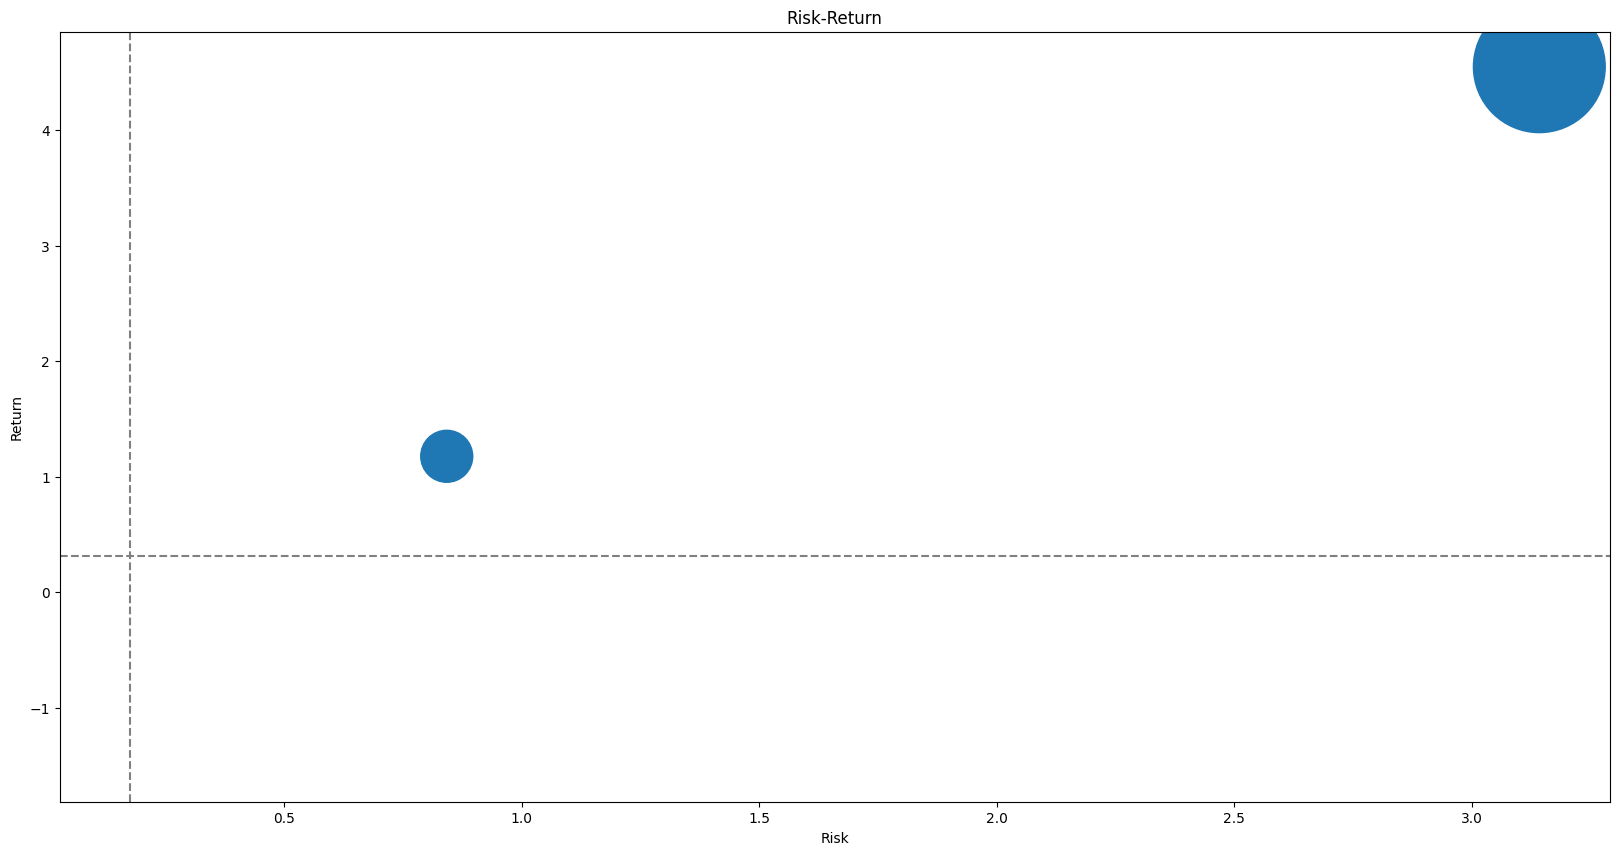

In [108]:
# Tính toán risk-return từng cổ phiếu
metrics = df.groupby('SYMBOL').agg({
    'PROFIT/LOSS (%)': ['mean', 'std'],
    'SUM': 'last'
})

plt.figure(figsize=(20,10))
plt.scatter(metrics[('PROFIT/LOSS (%)','std')], 
            metrics[('PROFIT/LOSS (%)','mean')],
            s=metrics[('SUM','last')]/1000)

# Vẽ đường hiệu quả
plt.axhline(y=df['CHANGE (%)'].mean(), color='gray', linestyle='--')
plt.axvline(x=df['CHANGE (%)'].std(), color='gray', linestyle='--')

plt.title('Risk-Return')
plt.xlabel('Risk')
plt.ylabel('Return')

CÔNG THỨC
<br>
<br>
Độ biến động (Volatility):<br>
σ = sqrt(Σ(Pi - μ)^2 / n)<br>
<br>
Value at Risk (VaR):<br>
VaR = Portfolio Value * (μ - z*σ)<br>
(z: 1.65 cho 95%, 2.33 cho 99%)<br>
<br>
Expected Shortfall (ES):<br>
ES = -E[X|X < -VaR]<br>
<br>
Tỷ lệ Sharpe:<br>
Sharpe = (E[R] - Rf) / σ<br>
<br>
Maximum Drawdown (MDD):<br>
MDD = (Peak - Trough) / Peak<br>
<br>
Beta:<br>
β = Cov(Ri, Rm) / Var(Rm)<br>